# Régression multiple — CO₂, masse et puissance des véhicules

*Machine Learning Specialization (DeepLearning.AI, cours 1 — semaine 2), appliqué au jeu de données ADEME des émissions des véhicules commercialisés en France.*

Dans le premier notebook, la masse seule ne suffisait pas à prédire le CO₂. J'ajoute ici d'autres variables — et je découvre en chemin que le jeu de données pose trois problèmes
qu'il faut régler avant toute modélisation.

**Plan**

0. Préparer les données — deux fuites et une unité d'observation trompeuse
1. Régression multiple sur les diesels
2. Régression multiple sur les essences
3. Feature engineering
4. Diagnostic des résidus et domaine de validité

## Partie 0 — Préparer les données

Le fichier compte 26 colonnes. Avant de choisir des variables explicatives, trois vérifications s'imposent : quelles colonnes sont dérivées de la cible, et une ligne correspond-elle bien à un véhicule ?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("data/vehicules.csv", sep=";", encoding="latin-1")

obj = df.select_dtypes(include="str").columns
df[obj] = df[obj].apply(lambda s: s.str.strip())

MOTORISATIONS = {"GO": "Diesel", "ES": "Essence"}

print(df.shape)
print(df.columns.tolist())

(20880, 26)
['lib_mrq_doss', 'lib_mod_doss', 'mrq_utac', 'mod_utac', 'dscom', 'cnit', 'tvv', 'energ', 'hybride', 'puiss_admin', 'puiss_max', 'puiss_heure', 'typ_boite_nb_rapp', 'conso_urb_93', 'conso_exurb', 'conso_mixte', 'co2_mixte', 'co_typ_1', 'hc', 'nox', 'hcnox', 'ptcl', 'masse_ordma_min', 'masse_ordma_max', 'champ_v9', 'date_maj']


### 0.1 — Première fuite : `conso_mixte`

L'analyse exploratoire donnait une corrélation de 0,976 entre consommation et CO₂.
Si le CO₂ est *calculé* à partir de la consommation, leur rapport doit être une constante propre à chaque carburant.

Diesel    moyenne =  26.15   ecart-type = 0.26   [24.8 ; 27.5]   n = 12675
Essence   moyenne =  23.27   ecart-type = 0.22   [21.0 ; 28.2]   n = 6934


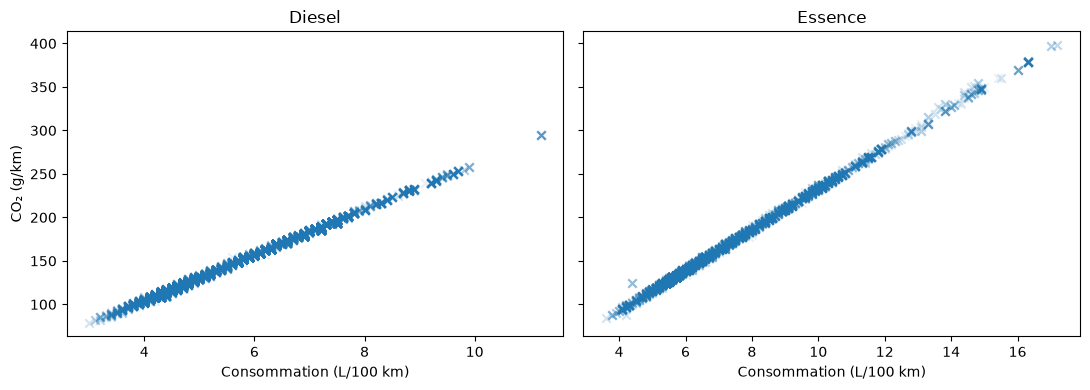

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, (code_energ, nom) in zip(axes, MOTORISATIONS.items()):
    cs = df[df["energ"] == code_energ][["conso_mixte", "co2_mixte"]].dropna()
    ratio = cs["co2_mixte"] / cs["conso_mixte"]
    print(f"{nom:8s}  moyenne = {ratio.mean():6.2f}   ecart-type = {ratio.std():.2f}"
          f"   [{ratio.min():.1f} ; {ratio.max():.1f}]   n = {len(cs)}")
    ax.scatter(cs["conso_mixte"], cs["co2_mixte"], marker="x", alpha=0.1)
    ax.set(xlabel="Consommation (L/100 km)", title=nom)

axes[0].set_ylabel("CO₂ (g/km)")
plt.tight_layout()
plt.show()

Le rapport `CO₂ / conso_mixte` est quasi constant : `26,15` en moyenne pour le diesel et `23,27` pour l'essence. Autrement dit, `CO₂ ≈ 26,15 × conso` pour le diesel et `CO₂ ≈ 23,27 × conso` pour l'essence. La consommation constitue donc une fuite de données, puisque le `CO₂` en est une fonction déterministe.

**Conclusion :** `conso_mixte`, `conso_urb_93` et `conso_exurb` sont exclues de la modélisation.

*(Je conserve `conso_mixte` dans le jeu de travail uniquement pour la démonstration chiffrée de la partie I, et non comme variable explicative.)*

### 0.2 — Seconde fuite : `puiss_admin`

Celle-ci est mieux cachée : la puissance administrative française se calcule depuis 1998 par une formule officielle qui fait intervenir le CO₂.

$$\text{CV} = \frac{\text{CO}_2}{45} + \left(\frac{P}{40}\right)^{1{,}6}$$

Si la formule reproduit la colonne, `puiss_admin` est une fonction déterministe de la cible.

In [3]:
pa_calc = df["co2_mixte"] / 45 + (df["puiss_max"] / 40) ** 1.6
ecart = (pa_calc.round() - df["puiss_admin"]).abs()

print(ecart.describe())
print(f"\nLignes reproduites exactement : {(ecart == 0).mean():.2%}")

count    20824.000000
mean         0.003073
std          0.062678
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.000000
dtype: float64

Lignes reproduites exactement : 99.47%


La formule reproduit la colonne à 99,47 %. `puiss_admin` constitue donc bien une fuite de données.

**Conclusion :** `puiss_admin` est exclue de la modélisation.

Cette fuite n'était pas facile à repérer, car la relation entre `puiss_admin` et `CO₂` n'est pas linéaire : l'exposant 1,6 la ferait passer sous le radar d'une simple matrice de corrélation.

Même raisonnement pour `co_typ_1`, `hc`, `nox`, `hcnox` et `ptcl` : ce sont des émissions mesurées sur le même cycle d'essai que le `CO₂`, donc des sorties de mesure et non des caractéristiques de conception.

### 0.3 — Une ligne n'est pas un véhicule

Le fichier déclare les véhicules au niveau de la **variante d'homologation** : mêmes masse, puissance et CO₂, mais numéros de dossier différents. Un modèle déclaré en 18 versions pèse 18 fois plus lourd dans la somme des carrés.

In [4]:
# Clés d'identification d'un véhicule réel.
# La masse est incluse volontairement : les finitions d'un même modèle ont des masses
# différentes, et cette variation est une information, pas un doublon.
CLES = ["lib_mrq_doss", "lib_mod_doss", "masse_ordma_min", "puiss_max", "co2_mixte"]

# Colonnes conservées dans le jeu de travail
GARDEES = ["lib_mrq_doss", "lib_mod_doss", "hybride", "typ_boite_nb_rapp",
           "masse_ordma_min", "puiss_max", "co2_mixte",
           "conso_mixte"]   # fuite — gardée pour la démonstration de la partie I

ESSENTIELLES = ["masse_ordma_min", "puiss_max", "co2_mixte"]


def prepare(code_energ):
    """Filtre sur une motorisation, supprime les NaN et les doublons d'homologation."""
    sous = df[df["energ"] == code_energ][GARDEES].dropna(subset=ESSENTIELLES)
    avant = len(sous)
    sous = sous.drop_duplicates(subset=CLES)
    sous["puiss_max²"] = sous["puiss_max"] ** 2
    print(f"{MOTORISATIONS[code_energ]:8s} {avant:6d} lignes -> {len(sous):5d} vehicules"
          f"   ({avant / len(sous):.1f} declarations par vehicule)")
    return sous


d_go = prepare("GO")
d_es = prepare("ES")

Diesel    12675 lignes ->  3077 vehicules   (4.1 declarations par vehicule)
Essence    6934 lignes ->  2406 vehicules   (2.9 declarations par vehicule)


Pour une motorisation donnée, il y a **plusieurs déclarations pour le même véhicule**. Ce constat n'a rien d'anecdotique : un véhicule déclaré plusieurs fois pèsera davantage qu'un véhicule déclaré une seule fois dans l'ajustement du modèle.

Pour la suite, nous travaillerons donc sur ces données dédupliquées.

In [5]:
def evalue(d, noms, cible="co2_mixte"):
    """Ajuste une régression et renvoie (modèle, R², MAE) sur les données d'entraînement."""
    X, y = d[noms].values, d[cible].values
    m = LinearRegression().fit(X, y)
    p = m.predict(X)
    return m, r2_score(y, p), mean_absolute_error(y, p)

## Partie I — Régression multiple sur les diesels

Deux modèles à comparer :

- **Modèle A** — masse + puissance : ce qu'un constructeur connaît au moment de la conception
- **Modèle B** — le même, plus `conso_mixte` : pour montrer chiffres à l'appui ce que fait une fuite

In [6]:
for nom, noms in [("A (conception)", ["masse_ordma_min", "puiss_max"]),
                  ("B (avec conso)", ["masse_ordma_min", "puiss_max", "conso_mixte"])]:
    m, r2, mae = evalue(d_go, noms)
    print(f"\nModele {nom} - R² = {r2:.3f}   MAE = {mae:.1f} g/km")
    for v, c in zip(noms, m.coef_):
        print(f"   {v:18s} {c:9.3f}")


Modele A (conception) - R² = 0.775   MAE = 12.5 g/km
   masse_ordma_min        0.085
   puiss_max             -0.028

Modele B (avec conso) - R² = 0.999   MAE = 0.9 g/km
   masse_ordma_min       -0.001
   puiss_max              0.005
   conso_mixte           26.423


Le coefficient de `conso_mixte` (26,423) est presque égal au rapport `CO₂ / conso_mixte` trouvé en 0.1 : c'est le facteur d'émission du gazole (≈ 2,64 kg de CO₂ par litre). Le CO₂ homologué étant calculé à partir de la consommation, le modèle B ne prédit rien, il retrouve une identité comptable — d'où le R² de 0,999 et l'effondrement des coefficients de `masse` et `puissance`.

**Conclusion :** `conso_mixte` est une fuite de données. Le modèle B est écarté pour la suite, précisément *à cause* de son bon score.

### Un résultat inattendu dans le modèle A

Le coefficient de la puissance est **négatif**. Littéralement : à masse égale, plus le véhicule est puissant, moins il émet. Physiquement absurde.

Deux hypothèses : multicolinéarité entre masse et puissance, ou effet conditionnel réel.

In [7]:
print("Correlation masse / puissance :",
      round(d_go[["masse_ordma_min", "puiss_max"]].corr().iloc[0, 1], 3), "\n")

for noms in [["masse_ordma_min"], ["puiss_max"], ["masse_ordma_min", "puiss_max"]]:
    _, r2, _ = evalue(d_go, noms)
    print(f"{str(noms):45s} R² = {r2:.4f}")

Correlation masse / puissance : 0.422 

['masse_ordma_min']                           R² = 0.7739
['puiss_max']                                 R² = 0.1197
['masse_ordma_min', 'puiss_max']              R² = 0.7747


Ce n'est pas de la multicolinéarité : la corrélation masse/puissance n'est que 0,422.

L'explication est la redondance. Le peu d'information que porte `puiss_max` est déjà contenu dans la masse : l'ajouter ne fait gagner que 0,0008 de R² (0,7739 → 0,7747).
Le coefficient de `-0,028` n'est donc pas un effet réel, mais un ajustement au bruit.

## Partie II — Régression multiple sur les essences

Même protocole, autre population.

In [8]:
for nom, noms in [("A (conception)", ["masse_ordma_min", "puiss_max"]),
                  ("B (avec conso)", ["masse_ordma_min", "puiss_max", "conso_mixte"])]:
    m, r2, mae = evalue(d_es, noms)
    print(f"\nModele {nom} - R² = {r2:.3f}   MAE = {mae:.1f} g/km")
    for v, c in zip(noms, m.coef_):
        print(f"   {v:18s} {c:9.3f}")


Modele A (conception) - R² = 0.789   MAE = 18.1 g/km
   masse_ordma_min        0.044
   puiss_max              0.340

Modele B (avec conso) - R² = 0.999   MAE = 1.0 g/km
   masse_ordma_min        0.000
   puiss_max              0.001
   conso_mixte           23.381


In [9]:
print("Correlation masse / puissance :",
      round(d_es[["masse_ordma_min", "puiss_max"]].corr().iloc[0, 1], 3), "\n")

for noms in [["masse_ordma_min"], ["puiss_max"], ["masse_ordma_min", "puiss_max"]]:
    _, r2, _ = evalue(d_es, noms)
    print(f"{str(noms):45s} R² = {r2:.4f}")

Correlation masse / puissance : 0.782 

['masse_ordma_min']                           R² = 0.6158
['puiss_max']                                 R² = 0.7618
['masse_ordma_min', 'puiss_max']              R² = 0.7886


Prise seule, `puiss_max` explique 76,18 % de la variance (contre 11,97 % chez le diesel), et son ajout à la masse fait gagner 0,1728 de R² (contre 0,0008). Son coefficient est positif et fort (0,340).

L'écart tient probablement à l'hétérogénéité de la population essence — de la citadine de 900 kg à la sportive de 545 kW — là où le diesel, concentré sur berlines et utilitaires, varie surtout en masse. C'est un résultat que l'analyse exploratoire ne pouvait pas donner : il fallait un modèle pour le voir.

**Une nuance**

La corrélation masse/puissance atteint ici 0,782 (contre 0,422 chez le diesel) : cette fois, la multicolinéarité est réelle. D'où le fait que 0,6158 + 0,7618 ne donne pas 0,7886 — l'information est partagée, pas additive.

**La fuite est confirmée**

Le coefficient de `conso_mixte` vaut 23,381 chez l'essence contre 26,423 chez le diesel, soit 2,34 et 2,64 kg de CO₂ par litre : les facteurs d'émission réels des deux carburants. Un « paramètre appris » qui change avec le carburant est une constante physique, pas un apprentissage.

Les deux carburants ne répondent donc pas au même modèle, ce qui conduit à chercher des variables plus fines.

## Partie III — Feature engineering

La suite se fait sur les essences, où la puissance porte de l'information.

### 3.1 — Un ratio puissance/masse ?

Intuition : le rapport puissance/masse capturerait le caractère sportif du véhicule.

In [10]:
d_es["ratio_p_m"] = d_es["puiss_max"] / d_es["masse_ordma_min"]

for noms in [["masse_ordma_min", "puiss_max"],
             ["masse_ordma_min", "puiss_max", "ratio_p_m"]]:
    _, r2, _ = evalue(d_es, noms)
    print(f"{str(noms):55s} R² = {r2:.4f}")

['masse_ordma_min', 'puiss_max']                        R² = 0.7886
['masse_ordma_min', 'puiss_max', 'ratio_p_m']           R² = 0.7894


Le ratio n'apporte presque rien : +0,0008 de R² (0,7886 → 0,7894). **Créer une variable ne garantit rien.**

### 3.2 — Un terme quadratique en puissance

Hypothèse physique : les émissions croissent plus vite que linéairement avec la puissance.

In [11]:
for noms in [["masse_ordma_min", "puiss_max"],
             ["masse_ordma_min", "puiss_max", "puiss_max²"],
             ["masse_ordma_min", "puiss_max²"]]:
    _, r2, _ = evalue(d_es, noms)
    print(f"{str(noms):55s} R² = {r2:.4f}")

['masse_ordma_min', 'puiss_max']                        R² = 0.7886
['masse_ordma_min', 'puiss_max', 'puiss_max²']          R² = 0.7995
['masse_ordma_min', 'puiss_max²']                       R² = 0.7991


Le terme quadratique apporte un gain net : +0,0109 de R² (0,7886 → 0,7995), à comparer aux +0,0008 du ratio. La relation entre puissance et CO₂ n'est donc pas tout à fait linéaire.

Aparté : les deux dernières lignes donnent quasiment le même R² (0,7995 et 0,7991). Une fois le terme quadratique présent, la puissance linéaire n'apporte plus rien *en moyenne*. Je garde malgré tout les deux termes : sans terme linéaire, la parabole est contrainte à un sommet en zéro, ce qui dégrade l'ajustement aux extrémités — la partie IV le montrera.

### 3.3 — La boîte de vitesses

Une boîte à 8 rapports maintient le moteur plus près de son rendement optimal qu'une boîte à 5. C'est une caractéristique de conception, donc une variable légitime.

Ajouter des indicatrices augmente **mécaniquement** le R² d'entraînement. À partir d'ici, j'évalue donc hors échantillon.

In [12]:
d_b = d_es.dropna(subset=["typ_boite_nb_rapp"]).copy()
print(f"{len(d_b)} vehicules avec boite renseignee\n")
print(d_b["typ_boite_nb_rapp"].value_counts(), "\n")

# Le format ADEME est "A 8", "M 6"... : type de boite + nombre de rapports.
# Le nombre de rapports est un nombre, pas une categorie.
d_b["boite_typ"] = d_b["typ_boite_nb_rapp"].str[0]
d_b["boite_rapp"] = d_b["typ_boite_nb_rapp"].str.extract(r"(\d+)").astype(float)

base = ["masse_ordma_min", "puiss_max", "puiss_max²"]
essais = [
    ("sans boite",       [],             []),
    ("boite brute",      [],             ["typ_boite_nb_rapp"]),
    ("boite decomposee", ["boite_rapp"], ["boite_typ"]),
]

y_b = d_b["co2_mixte"].values

print(f"{'Modele':20s} {'col.':>5s} {'R² train':>10s} {'R² test':>10s}")
for nom, num, cat in essais:
    X = pd.get_dummies(d_b[base + num + cat], columns=cat, drop_first=True).astype(float).values
    Xtr, Xte, ytr, yte = train_test_split(X, y_b, test_size=0.2, random_state=0)
    m = LinearRegression().fit(Xtr, ytr)
    print(f"{nom:20s} {X.shape[1]:5d} {r2_score(ytr, m.predict(Xtr)):10.4f}"
          f" {r2_score(yte, m.predict(Xte)):10.4f}")

2406 vehicules avec boite renseignee

typ_boite_nb_rapp
A 7    726
M 6    693
M 5    321
A 8    259
A 6    237
V 0     33
A 5     29
D 5     25
M 7     22
D 7     19
A 4     18
A 9     13
D 6      7
A 0      4
Name: count, dtype: int64 

Modele                col.   R² train    R² test
sans boite               3     0.7965     0.8105
boite brute             16     0.8424     0.8642
boite decomposee         7     0.8181     0.8297


La boîte de vitesses apporte le gain le plus net du notebook : le R² test passe de 0,8105 à 0,8642 avec l'encodage brut (`+0,0537`), soit **cinq fois le gain du terme quadratique**. C'est la variable la plus informative après la masse et la puissance.

La version décomposée (type + nombre de rapports) fait moins bien que la version brute (0,8297 contre 0,8642), ce qui est attendu : elle contraint le modèle. Elle suppose que l'effet du nombre de rapports est linéaire et s'ajoute à celui du type, là où l'encodage brut laisse chaque combinaison libre. Elle ne récupère qu'environ un tiers du gain, avec 4 colonnes au lieu de 13.

**Aucun signe de surajustement :** le R² test dépasse le R² train pour les trois modèles, y compris la version brute (0,8642 contre 0,8424). Le gain de l'encodage brut correspond donc bien à de l'information, pas à un ajustement au bruit.

## Partie IV — Diagnostic des résidus et domaine de validité

Un R² global ne dit pas *où* le modèle se trompe. Les résidus, si.

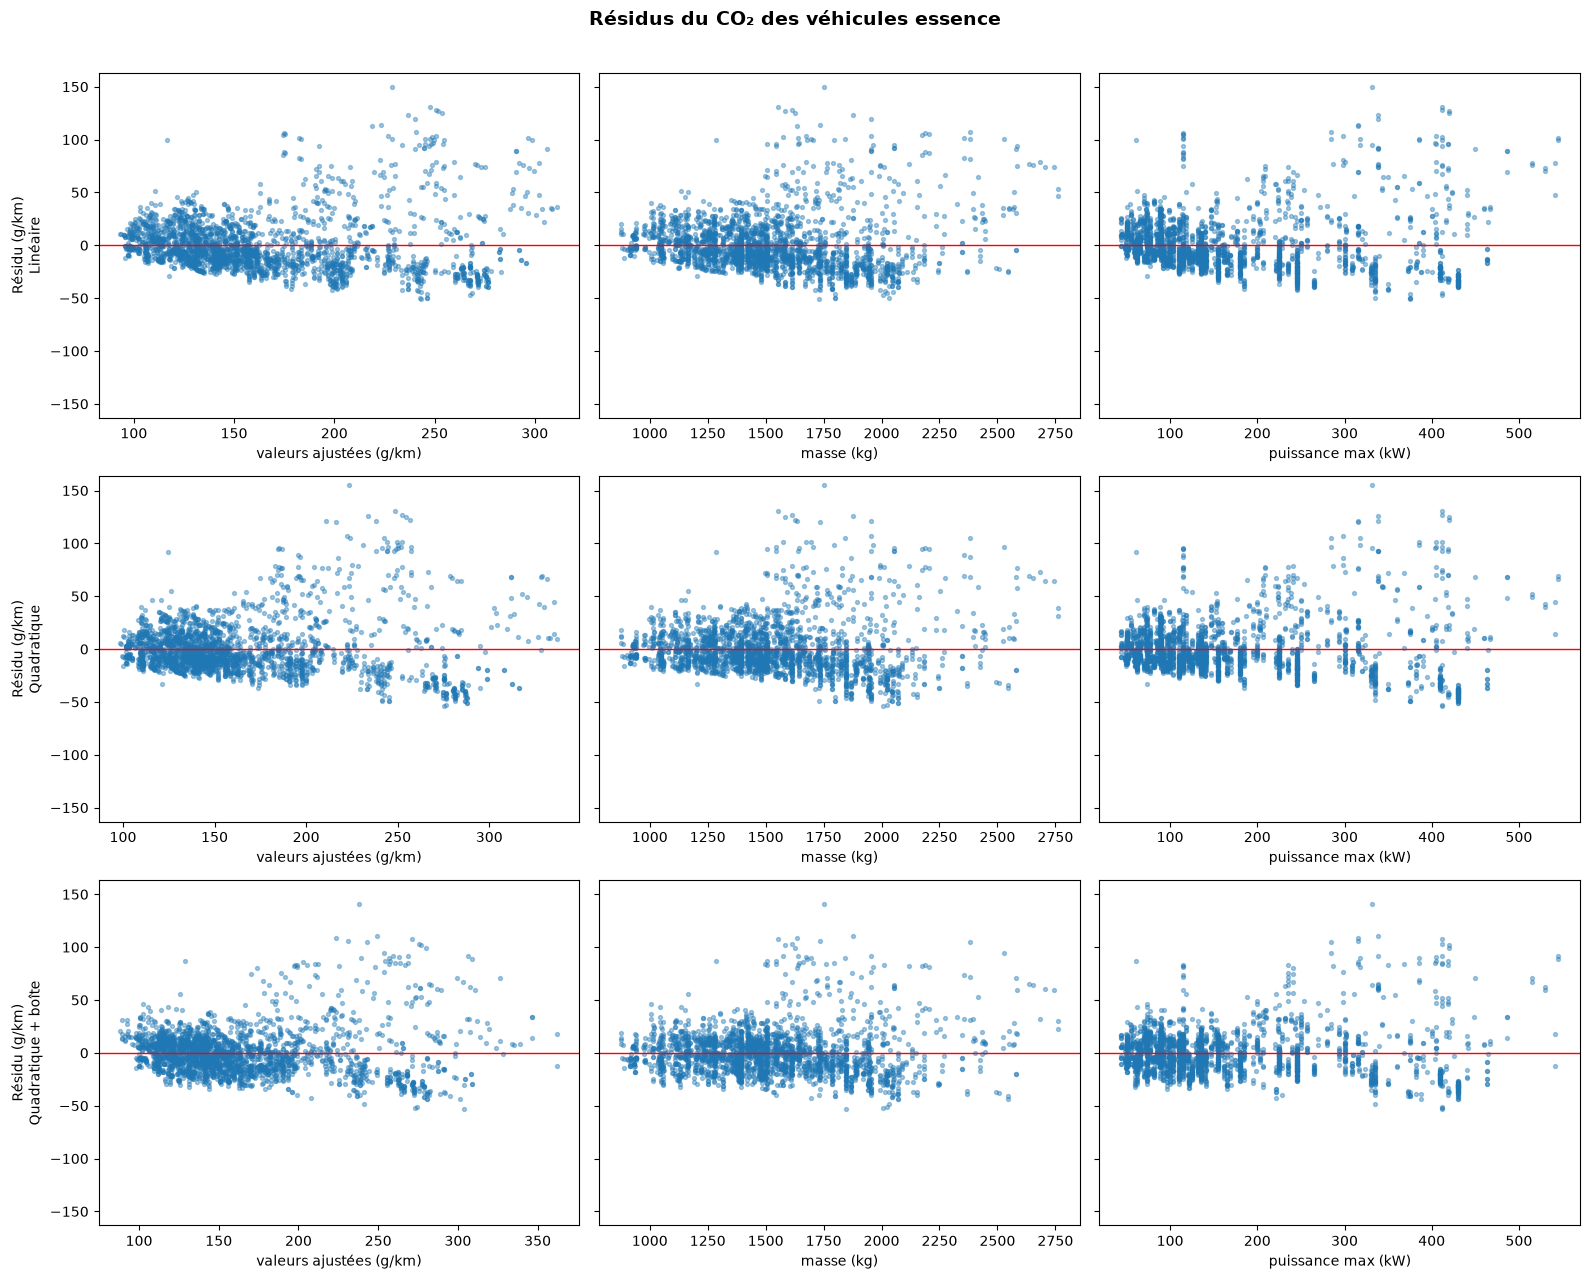

In [13]:
MODELES = [
    ("lin",   "Linéaire",            ["masse_ordma_min", "puiss_max"], []),
    ("quad",  "Quadratique",         ["masse_ordma_min", "puiss_max", "puiss_max²"], []),
    ("boite", "Quadratique + boîte", ["masse_ordma_min", "puiss_max", "puiss_max²"],
                                     ["typ_boite_nb_rapp"]),
]

y_es = d_b["co2_mixte"].values
fits = {}

for cle, _, num, cat in MODELES:
    X = pd.get_dummies(d_b[num + cat], columns=cat, drop_first=True).astype(float).values
    fits[cle] = LinearRegression().fit(X, y_es).predict(X)
    d_b[f"res_{cle}"] = y_es - fits[cle]

lim = d_b[[f"res_{c}" for c, *_ in MODELES]].abs().max().max() * 1.05

fig, axes = plt.subplots(3, 3, figsize=(16, 13), sharey=True)

for i, (cle, label, *_) in enumerate(MODELES):
    for j, (x, nom_x) in enumerate([(fits[cle], "valeurs ajustées (g/km)"),
                                    (d_b["masse_ordma_min"], "masse (kg)"),
                                    (d_b["puiss_max"], "puissance max (kW)")]):
        axes[i, j].scatter(x, d_b[f"res_{cle}"], s=8, alpha=0.4)
        axes[i, j].axhline(0, color="red", lw=1)
        axes[i, j].set(xlabel=nom_x, ylim=(-lim, lim))
    axes[i, 0].set_ylabel(f"Résidu (g/km)\n{label}")

fig.suptitle("Résidus du CO₂ des véhicules essence", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**Hétéroscédasticité.** La dispersion des résidus n'est pas constante : elle est resserrée sous 150 g/km ajustés — soit une masse inférieure à 1 500 kg et une puissance inférieure à 200 kW — puis s'élargit nettement au-delà. L'incertitude d'une prédiction dépend donc du véhicule, ce que le R² seul ne dit pas.

**Asymétrie.** L'étalement est unilatéral : les résidus positifs atteignent +150 g/km, les négatifs ne descendent pas sous −60. Le modèle sous-estime fortement certains véhicules lourds et puissants, mais n'en surestime jamais autant. C'est la signature d'une variable manquante : à masse et puissance données, rien dans le fichier ne distingue une berline profilée d'un SUV.

**Domaine de validité.** Le modèle est fiable sur le cœur du parc et se dégrade au-delà de 1 500 kg / 200 kW, précisément là où l'aérodynamique et la carrosserie prennent le pas.

In [14]:
freq = d_b["typ_boite_nb_rapp"].value_counts()
sous = d_b[d_b["typ_boite_nb_rapp"].isin(freq[freq >= 20].index)]

print(sous.groupby("typ_boite_nb_rapp", observed=True)[["res_quad"]]
          .agg(["size", "mean"]).round(1).sort_values(("res_quad", "mean")))

                  res_quad      
                      size  mean
typ_boite_nb_rapp               
A 7                    726 -12.2
A 8                    259  -4.3
V 0                     33   1.2
M 5                    321   2.7
M 6                    693   2.7
D 5                     25   9.1
A 6                    237  18.5
A 5                     29  22.7
M 7                     22  31.6


Avant l'ajout de la boîte, le modèle surestimait les automatiques à 7 rapports de 12 g/km et sous-estimait les A 5 et A 6 de 19 à 23 g/km : chez les automatiques, plus de rapports va avec moins de CO₂, le moteur restant plus près de son régime optimal. Mais l'effet n'est ni monotone (A 8 : −4,3, moins que A 7) ni transposable aux manuelles, plates en 5 et 6 rapports puis à +31,6 en 7.

C'est ce qui explique l'échec de la version décomposée en partie III : elle supposait un effet linéaire du nombre de rapports, additif avec le type. Aucune des deux hypothèses ne tient.

**Réserve.** `M 7` (22 véhicules) et `A 6` (237) sont peuplées de sportives. Le coefficient de boîte capte donc en partie un effet de segment, pas de transmission.

In [15]:
gros = (d_b.assign(abs_res=d_b["res_boite"].abs())
            .sort_values("abs_res", ascending=False)
            .drop_duplicates(["lib_mrq_doss", "lib_mod_doss"])
            .head(20).index)
print(d_b.loc[gros, ["lib_mrq_doss", "lib_mod_doss", "hybride", "typ_boite_nb_rapp",
                      "masse_ordma_min", "puiss_max", "co2_mixte",
                      "res_quad", "res_boite"]].to_string())

        lib_mrq_doss       lib_mod_doss hybride typ_boite_nb_rapp  masse_ordma_min  puiss_max  co2_mixte    res_quad   res_boite
13        ALFA ROMEO        AR8C SPIDER     non               M 6             1750      331.0      379.0  155.526563  141.236722
4142        MASERATI        GRANTURISMO     non               D 6             1875      338.0      360.0  126.300777  110.929030
573             AUDI           R8 COUPE     non               M 6             1635      316.0      332.0  121.295831  108.355709
3877           LEXUS          LEXUS LFA     non               A 6             1555      412.0      379.0  130.306197  107.629712
580             AUDI          R8 SPYDER     non               M 6             1735      316.0      337.0  120.429223  106.176209
12926  MERCEDES BENZ           CLASSE G     non               A 7             2380      285.0      348.0  105.277638  104.913426
3283     LAMBORGHINI          AVENTADOR     non               A 7             1640      545.0    

In [16]:
tranches = pd.cut(d_b["puiss_max"], [0, 75, 100, 150, 200, 300, 1000])
print(d_b.groupby(tranches, observed=True)[["res_quad", "res_boite"]]
          .agg(lambda s: s.abs().mean()).round(1))

             res_quad  res_boite
puiss_max                       
(0, 75]          10.9       11.7
(75, 100]        12.0       11.8
(100, 150]       13.3       12.2
(150, 200]       14.2       12.5
(200, 300]       21.6       16.9
(300, 1000]      36.0       30.0


**L'erreur est concentrée sur le haut du parc.** L'erreur absolue moyenne passe de 11,7 g/km sous 75 kW à 30,0 au-delà de 300 kW. Le gain de la boîte est lui aussi concentré là (21,6 → 16,9 au-dessus de 200 kW), et devient négatif en bas de gamme (10,9 → 11,7) : une variable peut réduire l'erreur globale et la dégrader sur un segment.

**Toujours dans le même sens.** Les 20 plus gros résidus sont tous positifs — le modèle sous-estime, il ne surestime jamais autant. Ce sont des supercars, à une exception près : la LADA 4X4, 1 285 kg et 61 kW, sous-estimée de 87 g/km. C'est le cas le plus instructif, parce que ni la masse ni la puissance ne peuvent l'expliquer. Ce qui manque est ailleurs : carrosserie, aérodynamique, génération du moteur.

**Domaine de validité.** Le modèle vaut pour le cœur du parc. Au-delà de 200 kW, il faut d'autres variables que le fichier ne contient pas.

## Ce que je retiens de la semaine 2

**Sur les données.** Trois colonnes sur 26 sont dérivées de la cible, et l'une d'elles (`puiss_admin`) est invisible dans une matrice de corrélation parce que la relation est non linéaire. Une ligne du fichier n'est pas un véhicule mais une variante d'homologation : 65 % des lignes essence sont des réplicats.

**Sur les variables.** La puissance explique `76 %` de la variance chez l'essence contre `12 %` chez le diesel, et son ajout à la masse fait gagner 0,17 de R² contre 0,0008. L'écart tient probablement à l'hétérogénéité de la population essence — de la citadine de 900 kg à la sportive de 545 kW — là où le diesel, concentré sur berlines et utilitaires, varie surtout en masse. Le gain du ratio `ratio_p_m` (masse / puissance) est presque négligeable. C'est prévisible - le terme est construit à partir des deux variables déjà présentes, il ne peut apporter que ce que leur combinaison non linéaire, ici négligeable. Le terme quadratique apporte un gain plus important - mais modeste.  *(à compléter — le contraste diesel/essence sur la puissance, le résultat négatif du ratio, le gain modeste du terme quadratique, le gain plus net de laboîte de vitesses.)*

**Sur la méthode.** L'analyse exploratoire montrait la dispersion des puissances chez l'essence, mais pas ce qu'elle impliquait : le modèle révèle que cette variable porte l'essentiel de l'information sur le CO₂ chez l'essence, et presque rien chez le diesel.

**Sur les modèles.** *(à compléter — la multicolinéarité chez l'essence et l'instabilité des coefficients qu'elle entraîne, la nécessité d'évaluer hors échantillon dès que le nombre de paramètres varie, le domaine de validité.)*

**Ce que je ferais ensuite.** Le fichier ne contient rien sur la carrosserie ni l'aérodynamique, qui sont les variables manquantes évidentes pour le haut du parc.